In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Imbalance handling
from sklearn.utils.class_weight import compute_class_weight

In [2]:
# Load Dataset
df = pd.read_csv("diabetic_data.csv")

In [3]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
# Convert readmitted to binary
df['readmitted'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

In [5]:
df['readmitted'].value_counts()

readmitted
0    90409
1    11357
Name: count, dtype: int64

In [6]:
df.shape

(101766, 50)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [8]:
# Count '?' values per column
missing_question = (df == '?').sum().sort_values(ascending=False)
missing_question[missing_question > 0]

weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

In [9]:
df.replace('?', np.nan, inplace=True)

In [10]:
df.isnull().sum().sort_values(ascending=False)

weight                      98569
max_glu_serum               96420
A1Cresult                   84748
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
encounter_id                    0
troglitazone                    0
tolbutamide                     0
pioglitazone                    0
rosiglitazone                   0
acarbose                        0
miglitol                        0
citoglipton                     0
tolazamide                      0
examide                         0
glipizide                       0
insulin                         0
glyburide-metformin             0
glipizide-metformin             0
glimepiride-pioglitazone        0
metformin-rosiglitazone         0
metformin-pioglitazone          0
change                          0
diabetesMed                     0
glyburide                       0
repaglinide   

In [11]:
# Drop columns with excessive missing values
df.drop(columns=['weight', 'payer_code', 'medical_specialty',
                 'max_glu_serum', 'A1Cresult'], inplace=True)

In [12]:
df.isnull().sum().sort_values(ascending=False)

race                        2273
diag_3                      1423
diag_2                       358
diag_1                        21
encounter_id                   0
tolazamide                     0
tolbutamide                    0
pioglitazone                   0
rosiglitazone                  0
acarbose                       0
miglitol                       0
troglitazone                   0
examide                        0
glipizide                      0
citoglipton                    0
insulin                        0
glyburide-metformin            0
glipizide-metformin            0
glimepiride-pioglitazone       0
metformin-rosiglitazone        0
metformin-pioglitazone         0
change                         0
diabetesMed                    0
glyburide                      0
chlorpropamide                 0
acetohexamide                  0
glimepiride                    0
gender                         0
age                            0
admission_type_id              0
discharge_

In [13]:
cat_cols = df.select_dtypes(include=['object']).columns

In [14]:
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [15]:
df.duplicated().sum()

np.int64(0)

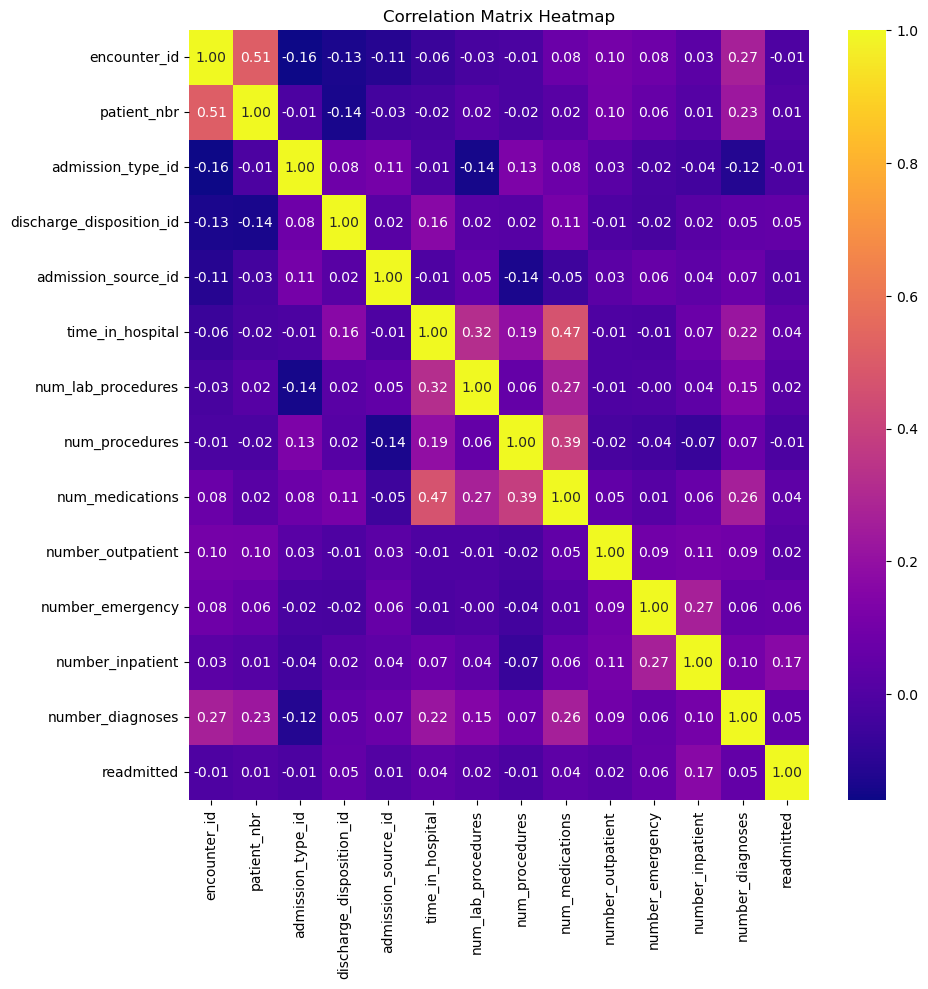

In [16]:
# Correlation Matrix
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True), cmap='plasma',  annot=True,fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

In [17]:
encoder = LabelEncoder()
for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

In [18]:
df.drop(columns=['encounter_id', 'patient_nbr'], inplace=True)

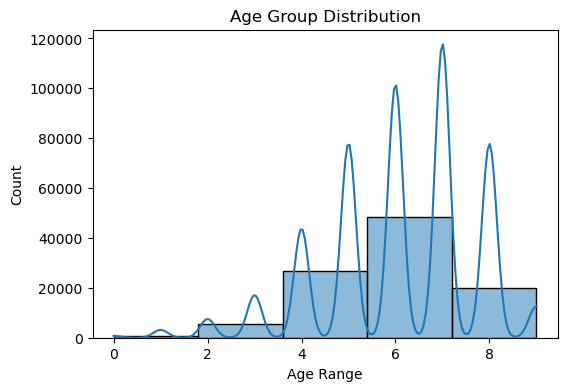

In [19]:
# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['age'], kde=True, bins=5)
plt.title("Age Group Distribution")
plt.xlabel("Age Range")
plt.ylabel("Count")
plt.show()

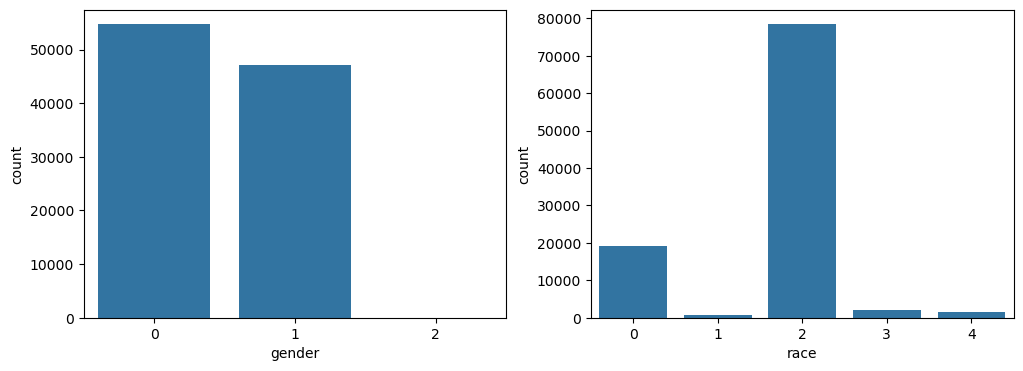

In [20]:
# Gender & Race Distribution
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.countplot(x='gender', data=df, ax=ax[0])
sns.countplot(x='race', data=df, ax=ax[1])
plt.show()

In [21]:
X = df.drop('readmitted', axis=1)
y = df['readmitted']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

In [25]:
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(0.5628128197328761), 1: np.float64(4.480079242791107)}

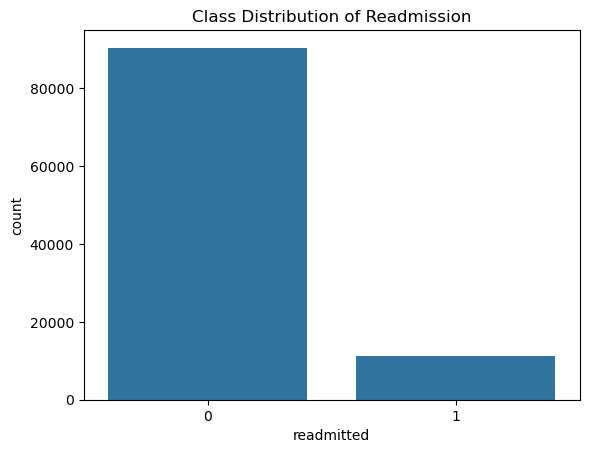

In [26]:
sns.countplot(x=y)
plt.title("Class Distribution of Readmission")
plt.show()

# Logistic Regression

In [27]:
lr = LogisticRegression(class_weight=class_weight_dict, max_iter=1000)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,"{0: np.float64(0.5628128197328761), 1: np.float64(4.480079242791107)}"
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [28]:
y_pred_lr = lr.predict(X_test)

In [29]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.6686646359437949


In [30]:
print(confusion_matrix(y_test, y_pred_lr))

[[12439  5644]
 [ 1100  1171]]


In [31]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.92      0.69      0.79     18083
           1       0.17      0.52      0.26      2271

    accuracy                           0.67     20354
   macro avg       0.55      0.60      0.52     20354
weighted avg       0.84      0.67      0.73     20354



# Decision Tree Classifier

In [32]:
dt = DecisionTreeClassifier(
    max_depth=10,
    class_weight=class_weight_dict,
    random_state=42
)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,"{0: np.float64(0.5628128197328761), 1: np.float64(4.480079242791107)}"


In [33]:
y_pred_dt = dt.predict(X_test)

In [34]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.6043038223445023


In [35]:
print(confusion_matrix(y_test, y_pred_dt))

[[10892  7191]
 [  863  1408]]


In [36]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.93      0.60      0.73     18083
           1       0.16      0.62      0.26      2271

    accuracy                           0.60     20354
   macro avg       0.55      0.61      0.49     20354
weighted avg       0.84      0.60      0.68     20354



# Random Forest Classifier

In [37]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight=class_weight_dict,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
y_pred_rf = rf.predict(X_test)

In [39]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.8887687923749632


In [40]:
print(confusion_matrix(y_test, y_pred_rf))

[[18078     5]
 [ 2259    12]]


In [41]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.71      0.01      0.01      2271

    accuracy                           0.89     20354
   macro avg       0.80      0.50      0.48     20354
weighted avg       0.87      0.89      0.84     20354



# Gradient Boosting Classifier

In [42]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [43]:
y_pred_gb = gb.predict(X_test)

In [44]:
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.8887687923749632


In [45]:
print(confusion_matrix(y_test, y_pred_gb))

[[18064    19]
 [ 2245    26]]


In [46]:
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.58      0.01      0.02      2271

    accuracy                           0.89     20354
   macro avg       0.73      0.51      0.48     20354
weighted avg       0.85      0.89      0.84     20354

